In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.metrics import mean_squared_error
import statsmodels.api as sm
from itertools import combinations
import matplotlib.pyplot as plt



In [2]:
# a)
n = 100
X = np.random.normal(0, 1, n)
epsilon = np.random.normal(0, 1, n)


In [3]:
# b)
beta0, beta1, beta2, beta3 = 1, 2, 3, 4
Y = beta0 + beta1*X + beta2*X**2 + beta3*X**3 + epsilon

In [4]:
# c)

data = pd.DataFrame({'Y': Y})
for i in range(1, 11):
    data[f'X{i}'] = X**i

data

,Y,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10
0,-4.286762,-1.245694,1.551753,-1.933009,2.407937,-2.999552,3.736524,-4.654565,5.798162,-7.222734,8.997315
1,-2.230792,-0.984464,0.969169,-0.954111,0.939288,-0.924695,0.910328,-0.896185,0.882262,-0.868554,0.855060
2,4.038701,0.579932,0.336321,0.195043,0.113112,0.065597,0.038042,0.022062,0.012794,0.007420,0.004303
3,21.576093,1.410169,1.988576,2.804227,3.954434,5.576418,7.863691,11.089131,15.637545,22.051576,31.096443
4,-0.514087,-0.461776,0.213237,-0.098468,0.045470,-0.020997,0.009696,-0.004477,0.002068,-0.000955,0.000441
...,...,...,...,...,...,...,...,...,...,...,...
95,72.483825,2.322537,5.394180,12.528185,29.097178,67.579283,156.955413,364.534817,846.645748,1966.366415,4566.959542
96,12.912480,1.103031,1.216678,1.342033,1.480305,1.632822,1.801054,1.986619,2.191302,2.417075,2.666109
97,-0.449594,-0.413396,0.170896,-0.070648,0.029205,-0.012073,0.004991,-0.002063,0.000853,-0.000353,0.000146
98,-7.990669,-1.442721,2.081443,-3.002941,4.332405,-6.250450,9.017654,-13.009956,18.769732,-27.079481,39.068128


In [5]:
def forward_selection(data, response):
    remaining = set(data.columns)
    remaining.remove(response)
    selected = []
    current_score, best_new_score = np.inf, np.inf

    while remaining:
        scores_with_candidates = []
        for candidate in remaining:
            formula = "{} ~ {}".format(response, ' + '.join(selected + [candidate]))
            # formuła w stylu R: "Y ~ X1 + X2 + X3"
            model = sm.OLS.from_formula(formula, data).fit()
            scores_with_candidates.append((model.aic, candidate))
            # wartosc kryterium informacyjnego AIC

        scores_with_candidates.sort(reverse=False)
        best_new_score, best_candidate = scores_with_candidates[0]
        if current_score > best_new_score:
            remaining.remove(best_candidate)
            selected.append(best_candidate)
            current_score = best_new_score
        else:
            break
    formula = "{} ~ {}".format(response, ' + '.join(selected))
    model = sm.OLS.from_formula(formula, data).fit()
    return model, selected

In [6]:
fwd_model, fwd_selected = forward_selection(data, 'Y')
print("Selected variables (forward):", fwd_selected)
print(fwd_model.summary())

Selected variables (forward): ['X3', 'X2', 'X1']
                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.996
Model:                            OLS   Adj. R-squared:                  0.996
Method:                 Least Squares   F-statistic:                     8408.
Date:                Tue, 18 Nov 2025   Prob (F-statistic):          4.76e-116
Time:                        10:43:22   Log-Likelihood:                -131.83
No. Observations:                 100   AIC:                             271.7
Df Residuals:                      96   BIC:                             282.1
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Int

In [7]:
# d)
def backward_selection(data, response):
    selected = list(data.columns)
    selected.remove(response)
    current_score = np.inf

    while selected:
        scores_with_candidates = []
        for combo in combinations(selected, len(selected) - 1):
            formula = "{} ~ {}".format(response, ' + '.join(combo))
            model = sm.OLS.from_formula(formula, data).fit()
            scores_with_candidates.append((model.aic, combo))

        scores_with_candidates.sort(reverse=False)
        best_new_score, best_candidate = scores_with_candidates[0]
        if best_new_score < current_score:
            current_score = best_new_score
            selected = list(best_candidate)
        else:
            break

    formula = "{} ~ {}".format(response, ' + '.join(selected))
    model = sm.OLS.from_formula(formula, data).fit()
    return model, selected

In [8]:
bwd_model, bwd_selected = backward_selection(data, 'Y')
print("Selected variables (backward):", bwd_selected)
print(bwd_model.summary())

Selected variables (backward): ['X1', 'X2', 'X3']
                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.996
Model:                            OLS   Adj. R-squared:                  0.996
Method:                 Least Squares   F-statistic:                     8408.
Date:                Tue, 18 Nov 2025   Prob (F-statistic):          4.76e-116
Time:                        10:43:23   Log-Likelihood:                -131.83
No. Observations:                 100   AIC:                             271.7
Df Residuals:                      96   BIC:                             282.1
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
In

C:\Users\Pytla\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 4.7255190737500925, tolerance: 2.1061995489324263
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\Pytla\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 8.395752825159889, tolerance: 2.1061995489324263
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\Pytla\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 9.26269100343552, tolerance: 2.1061995489324263
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\Pytla\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681:

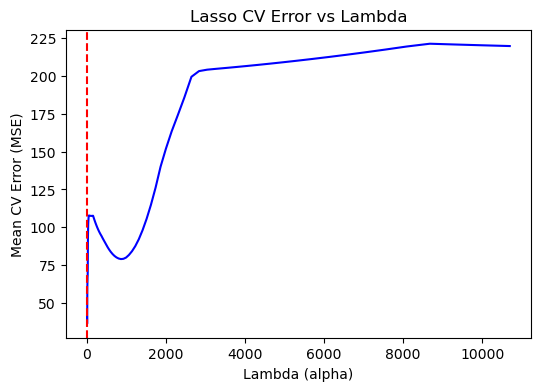

Optimal alpha: 12.2957208951568
Lasso coefficients:
X1     0.000000
X2     0.000000
X3     0.000000
X4     0.000000
X5     0.000000
X6     0.000000
X7     0.587070
X8     0.025706
X9    -0.081924
X10    0.000000
dtype: float64


In [9]:
# e)
X_mat = data.drop(columns=['Y']).values
lasso = LassoCV(cv=10, random_state=42)
lasso.fit(X_mat, Y)

plt.figure(figsize=(6,4))
plt.plot(lasso.alphas_, np.mean(lasso.mse_path_, axis=1), 'b-')
plt.axvline(lasso.alpha_, color='r', linestyle='--')
plt.xlabel("Lambda (alpha)")
plt.ylabel("Mean CV Error (MSE)")
plt.title("Lasso CV Error vs Lambda")
plt.show()

print("Optimal alpha:", lasso.alpha_)
coeffs = pd.Series(lasso.coef_, index=data.columns[1:])
print("Lasso coefficients:")
print(coeffs)


In [10]:
# f) 
beta0, beta7 = 2, 10
Y2 = beta0 + beta7 * X**7 + epsilon

data2 = pd.DataFrame({"Y": Y2})
for i in range(1,11):
    data2[f"X{i}"] = X ** i

X2_mat = data2.drop(columns=['Y']).values
lasso2 = LassoCV(cv=10, random_state=42)
lasso2.fit(X2_mat, Y2)

coeffs2 = pd.Series(lasso2.coef_, index=data2.columns[1:])
print("Lasso coefficients for model with X^7:")
print(coeffs2)

# lasso nie potrafi odroznic ktora potega jest naprawde odpowiedzialna za Y, wiec wybiera X^9
# ktore jest blisko X^7

Lasso coefficients for model with X^7:
X1     0.000000
X2    -0.000000
X3     0.000000
X4    -0.000000
X5     0.000000
X6    -0.000000
X7     0.000000
X8    -0.000000
X9     1.601523
X10   -0.000000
dtype: float64
